In [57]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [58]:
df = pd.read_csv("C:/Users/ragu/capstone_pj/dataset/fraud_dataset.csv")
df.head()

,Claim_ID,Claim_Date,Policyholder_ID,Claim_Amount,Claim_Type,Suspicious_Flags,Fraud_Label
0,C00001,13-04-2023,P00001,10711.01,Vehicle,False,0
1,C00002,15-12-2023,P00002,11528.26,Vehicle,True,1
2,C00003,28-09-2023,P00003,14106.24,Vehicle,False,0
3,C00004,17-04-2023,P00004,13242.61,Vehicle,False,0
4,C00005,13-03-2023,P00005,9133.98,Medical,False,0


In [59]:
# change columns to lowercase
df.columns = df.columns.str.lower()

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   claim_id          100000 non-null  object 
 1   claim_date        100000 non-null  object 
 2   policyholder_id   100000 non-null  object 
 3   claim_amount      100000 non-null  float64
 4   claim_type        100000 non-null  object 
 5   suspicious_flags  100000 non-null  bool   
 6   fraud_label       100000 non-null  int64  
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 4.7+ MB


In [61]:
df["suspicious_flags"] = df["suspicious_flags"].astype(int)

In [62]:
df.describe()

,claim_amount,suspicious_flags,fraud_label
count,100000.000000,100000.00000,100000.000000
mean,12814.151447,0.15177,0.148360
std,5158.758713,0.35880,0.355458
min,500.000000,0.00000,0.000000
25%,9159.890000,0.00000,0.000000
50%,11947.685000,0.00000,0.000000
75%,15230.517500,0.00000,0.000000
max,38707.650000,1.00000,1.000000


In [63]:
df.describe(include="all")

,claim_id,claim_date,policyholder_id,claim_amount,claim_type,suspicious_flags,fraud_label
count,100000,100000,100000,100000.000000,100000,100000.00000,100000.000000
unique,100000,365,100000,NaN,3,NaN,NaN
top,C00001,26-05-2023,P00001,NaN,Vehicle,NaN,NaN
freq,1,319,1,NaN,60049,NaN,NaN
mean,NaN,NaN,NaN,12814.151447,NaN,0.15177,0.148360
std,NaN,NaN,NaN,5158.758713,NaN,0.35880,0.355458
min,NaN,NaN,NaN,500.000000,NaN,0.00000,0.000000
25%,NaN,NaN,NaN,9159.890000,NaN,0.00000,0.000000
50%,NaN,NaN,NaN,11947.685000,NaN,0.00000,0.000000
75%,NaN,NaN,NaN,15230.517500,NaN,0.00000,0.000000


In [64]:
df.duplicated().sum()  

0

In [65]:
# EDA 
df.head(10)

,claim_id,claim_date,policyholder_id,claim_amount,claim_type,suspicious_flags,fraud_label
0,C00001,13-04-2023,P00001,10711.01,Vehicle,0,0
1,C00002,15-12-2023,P00002,11528.26,Vehicle,1,1
2,C00003,28-09-2023,P00003,14106.24,Vehicle,0,0
3,C00004,17-04-2023,P00004,13242.61,Vehicle,0,0
4,C00005,13-03-2023,P00005,9133.98,Medical,0,0
5,C00006,08-07-2023,P00006,15375.98,Vehicle,0,0
6,C00007,21-01-2023,P00007,7190.63,Vehicle,1,1
7,C00008,13-04-2023,P00008,14651.56,Vehicle,0,0
8,C00009,02-05-2023,P00009,7217.05,Medical,0,0
9,C00010,03-08-2023,P00010,12382.64,Vehicle,0,0


In [66]:
# Fraud label is target variable
# 0 = Not Fraud, 1 = Fraud

<Axes: xlabel='fraud_label', ylabel='Count'>

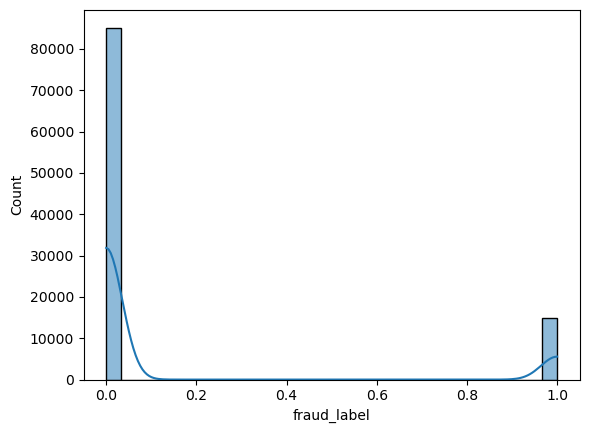

In [67]:
# Univariate Analysis
sns.histplot(df["fraud_label"], bins=30, kde=True)

<Axes: xlabel='suspicious_flags', ylabel='Count'>

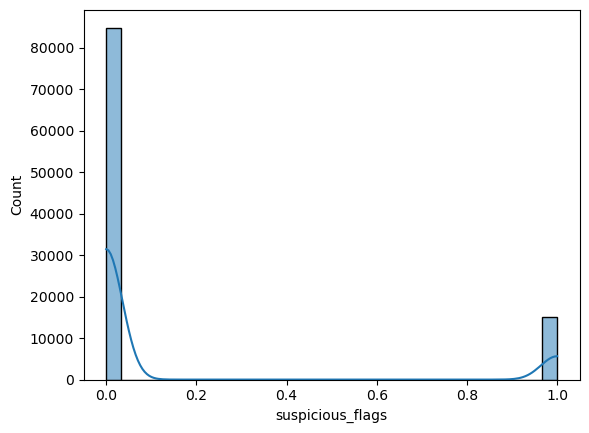

In [68]:
sns.histplot(df["suspicious_flags"], bins=30, kde=True)

<Axes: xlabel='claim_amount', ylabel='Count'>

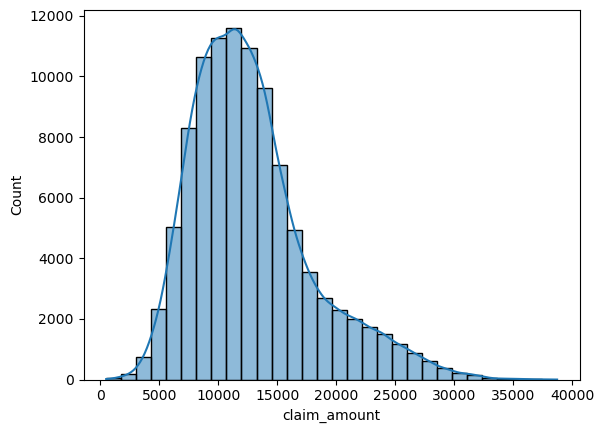

In [69]:
sns.histplot(df["claim_amount"], bins=30, kde=True)

<Axes: xlabel='claim_type', ylabel='Count'>

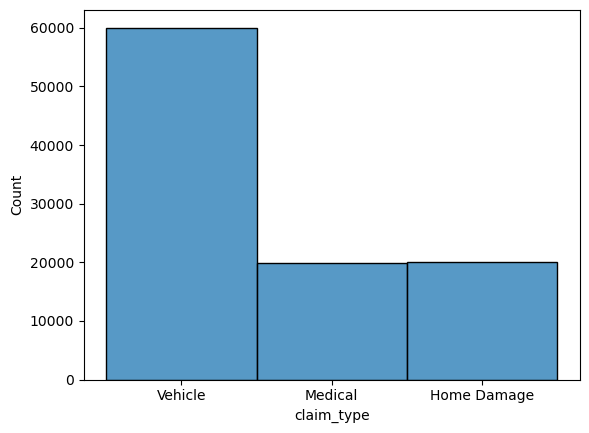

In [70]:
sns.histplot(df["claim_type"])

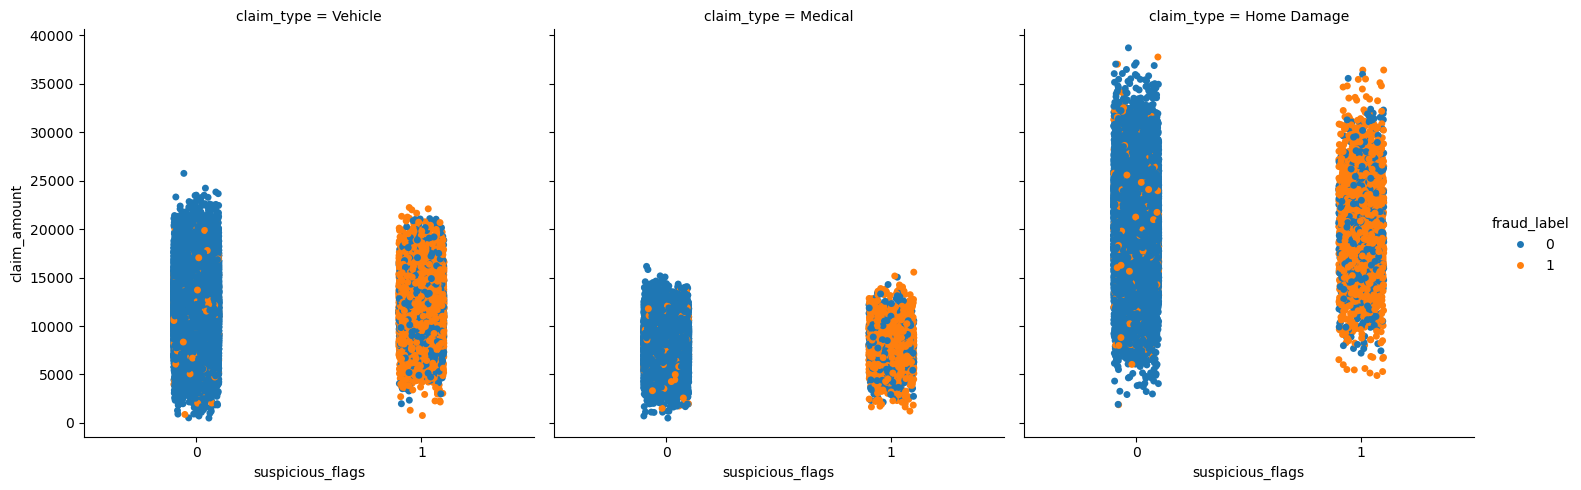

In [71]:
sns.catplot(data=df, x="suspicious_flags", y="claim_amount", hue="fraud_label", col="claim_type")

C:\Users\ragu\AppData\Local\Temp\ipykernel_4896\2091671940.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x="claim_type", y="claim_amount", palette="Set2")


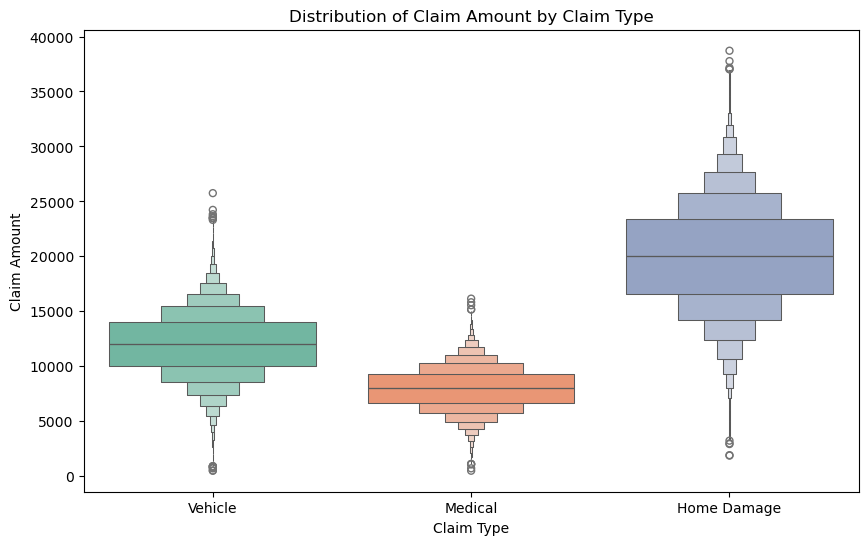

In [72]:
plt.figure(figsize=(10, 6))
sns.boxenplot(data=df, x="claim_type", y="claim_amount", palette="Set2")
plt.title("Distribution of Claim Amount by Claim Type")
plt.xlabel("Claim Type")
plt.ylabel("Claim Amount")
plt.show()

In [73]:
# Suspicious flags and fraud label are correlated (0.66)

In [74]:
# Bivariate Analysis

<Axes: xlabel='fraud_label', ylabel='claim_amount'>

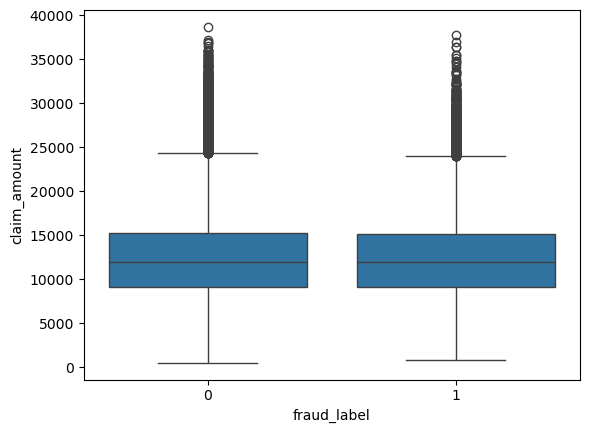

In [75]:
sns.boxplot(x="fraud_label", y="claim_amount", data=df)

<Axes: xlabel='fraud_label', ylabel='suspicious_flags'>

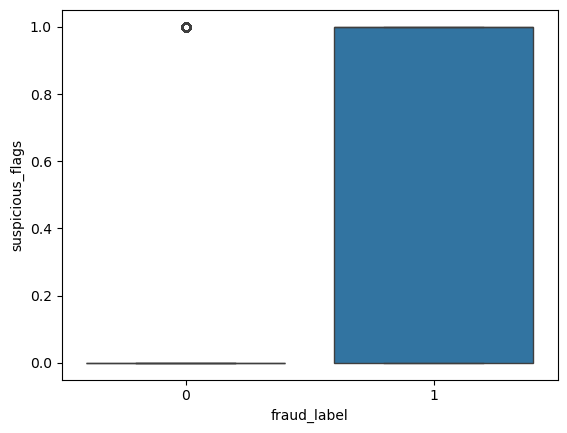

In [76]:
sns.boxplot(x="fraud_label", y="suspicious_flags", data=df)

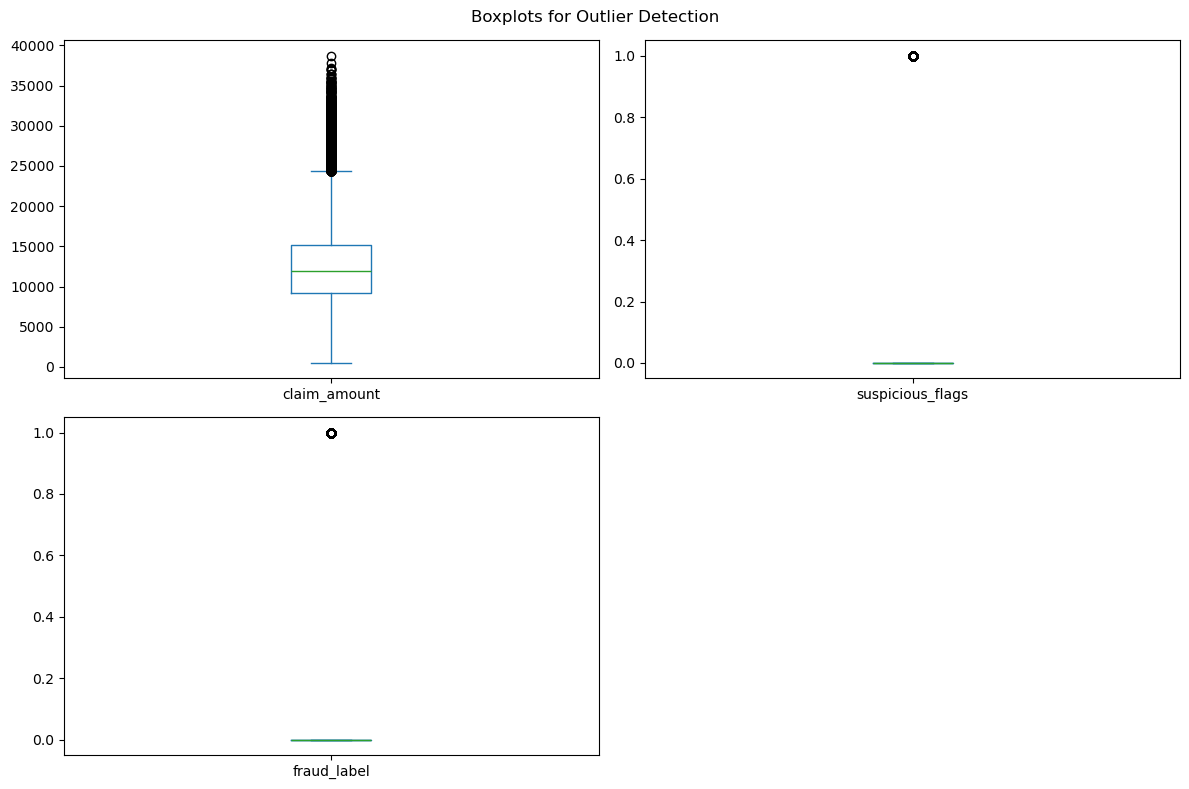

In [77]:
# Check for outliers

df.select_dtypes(include='number').plot(kind='box', subplots=True, layout=(2, 2), figsize=(12, 8), sharex=False, sharey=False)
plt.suptitle("Boxplots for Outlier Detection")
plt.tight_layout()
plt.show()

In [78]:
# one_hot_encoding
one_hot_encode = pd.get_dummies(df["claim_type"], prefix="claim_type").astype(int)
df.drop("claim_type", axis=1, inplace=True)
feature = pd.concat([df, one_hot_encode], axis=1)

In [79]:
feature.head()

,claim_id,claim_date,policyholder_id,claim_amount,suspicious_flags,fraud_label,claim_type_Home Damage,claim_type_Medical,claim_type_Vehicle
0,C00001,13-04-2023,P00001,10711.01,0,0,0,0,1
1,C00002,15-12-2023,P00002,11528.26,1,1,0,0,1
2,C00003,28-09-2023,P00003,14106.24,0,0,0,0,1
3,C00004,17-04-2023,P00004,13242.61,0,0,0,0,1
4,C00005,13-03-2023,P00005,9133.98,0,0,0,1,0


<Axes: xlabel='fraud_label', ylabel='claim_type_Vehicle'>

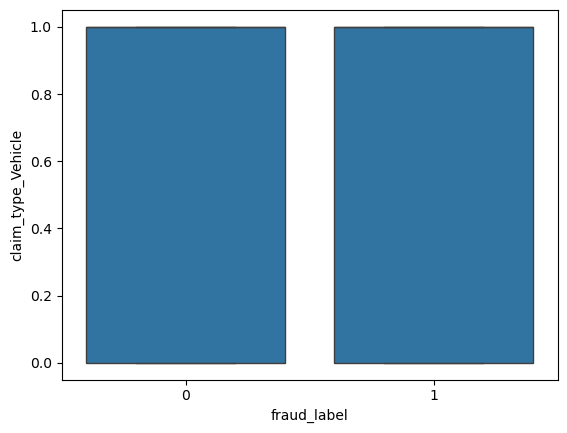

In [80]:
sns.boxplot(x="fraud_label", y="claim_type_Vehicle", data= feature)

<Axes: xlabel='fraud_label', ylabel='claim_type_Medical'>

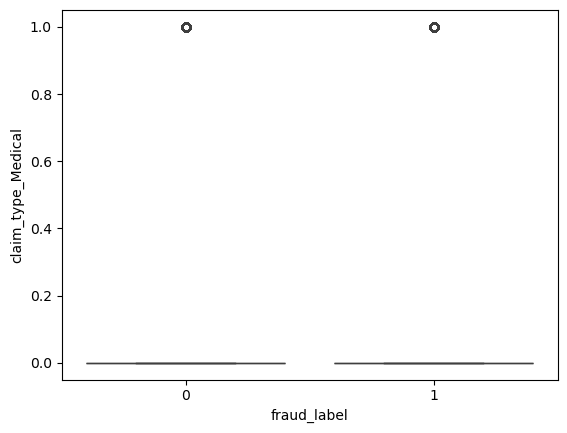

In [81]:
sns.boxplot(x="fraud_label", y="claim_type_Medical", data= feature)

<Axes: xlabel='fraud_label', ylabel='claim_type_Home Damage'>

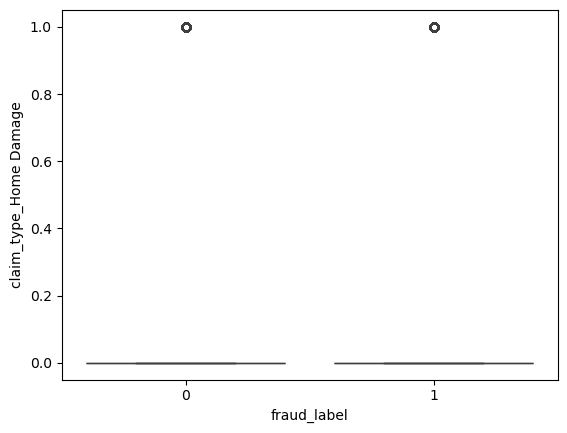

In [83]:
sns.boxplot(x="fraud_label", y="claim_type_Home Damage", data= feature)

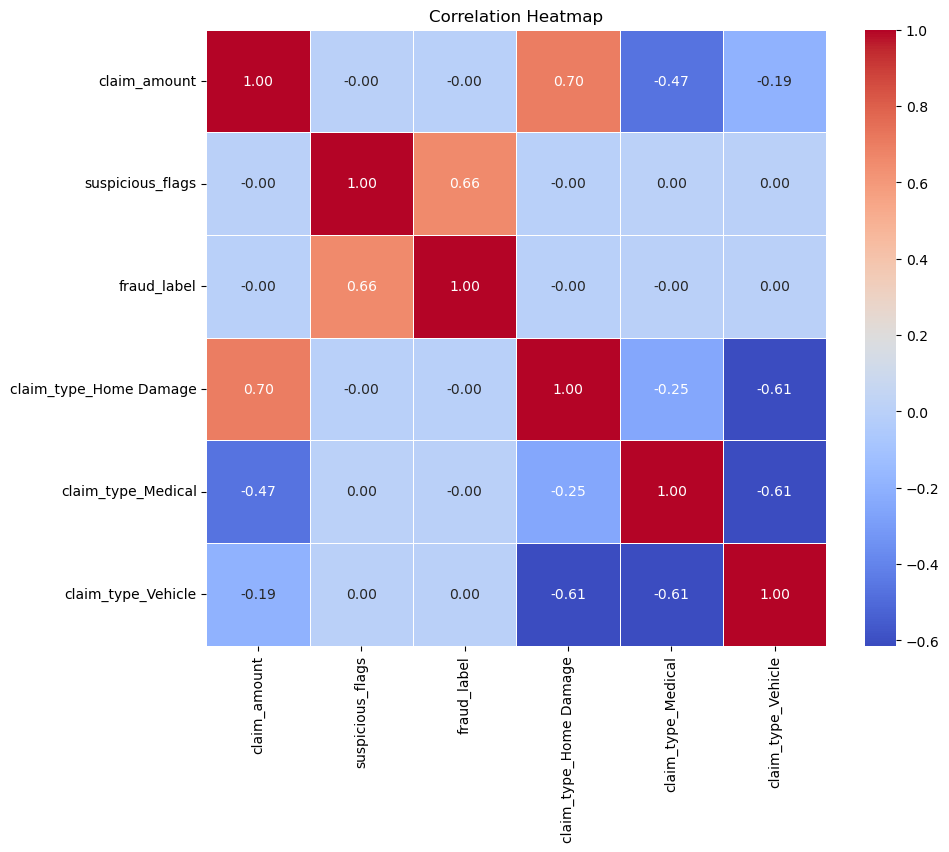

In [84]:
# Correlation Analysis
corr = feature.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Correlation Analysis (positive correlation)
# suspicious_flags(0.66)
# Negetive correlation
# No negetive corrilation with fraud_label

In [ ]:
# Model Building

In [85]:
# select the feature
x = feature.drop(columns=["claim_id", "claim_date", "policyholder_id", "fraud_label"])
y = feature["fraud_label"]

In [86]:
# over samplt the minority class
smote = SMOTE()
x_res, y_res = smote.fit_resample(x,y)

In [87]:
x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2, stratify=y_res, random_state=42)

In [ ]:
# feature scaling (not done)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [90]:
model = RandomForestClassifier()

In [91]:
model.fit(x_train, y_train)

RandomForestClassifier()

In [93]:
y_pred = model.predict(x_test)

In [94]:
# evaluate the model using metrics
print(f"accuracy score : {accuracy_score(y_test,y_pred):.2f}")
print(f"precision score : {precision_score(y_test,y_pred):.2f}")
print(f"recall score : {recall_score(y_test,y_pred):.2f}")
print(f"f1 score : {f1_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

accuracy score : 0.80
precision score : 0.80
recall score : 0.81
f1 score : 0.80
              precision    recall  f1-score   support

           0       0.81      0.79      0.80     17033
           1       0.80      0.81      0.80     17033

    accuracy                           0.80     34066
   macro avg       0.80      0.80      0.80     34066
weighted avg       0.80      0.80      0.80     34066



In [ ]:
# Save the model

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])
pipeline.fit(x_train, y_train)
joblib.dump(pipeline, 'fru_det_pilin.pkl')

['fru_det_pilin.pkl']

In [96]:
joblib.load('fru_det_pilin.pkl')

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier())])

In [ ]:
# 10711.01  0	0	0	0	1 (genuine)
# 11528.26	1	1	0	0	1 (Fraud)

In [ ]:
# User input
clime_amount = int(input("Enter claim amount: "))
suspicious_flags = int(input("Enter suspicious flags (0 or 1): "))
claim_type_vehicle = int(input("Is claim type Vehicle? (0 or 1): "))
claim_type_medical = int(input("Is claim type Medical? (0 or 1): "))
claim_type_home_damage = int(input("Is claim type Home Damage? (0 or 1): "))

user_input = [[
    clime_amount,
    suspicious_flags,
    claim_type_vehicle,
    claim_type_medical,
    claim_type_home_damage
]]

In [ ]:
# Make the prediction

prediction = pipeline.predict(user_input)[0]
label = "Fraud" if prediction == 1 else "Genuine"
print("Prediction:", label)

Prediction: Fraud


c:\Users\ragu\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
